In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ConceptAnalyzer,
    ScanpathsAnalyzer,
    VoiceTranscription
)


config = CustomConfig('../configs/config.yaml')
loader = DataLoader(config, root='../')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-29.430227,13.225609,4885


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260820_194424,-17.470503,-27.896498,713
1,20260823_120449,-25.108124,-2.134489,1808
2,20260823_120940,-14.057533,42.737009,1197
3,20260823_140228,-57.006374,28.164038,1111
4,20260823_183539,-102.745605,105.535924,56


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260820_194424,0,1.179036,-40.322591,84
1,20260820_194424,1,-8.599895,19.737567,82
2,20260820_194424,2,19.112971,8.852228,88
3,20260820_194424,3,26.683356,26.050495,82
4,20260820_194424,4,-73.648003,-51.091092,72


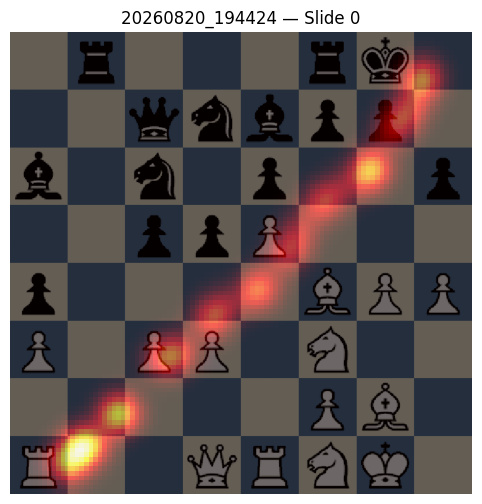

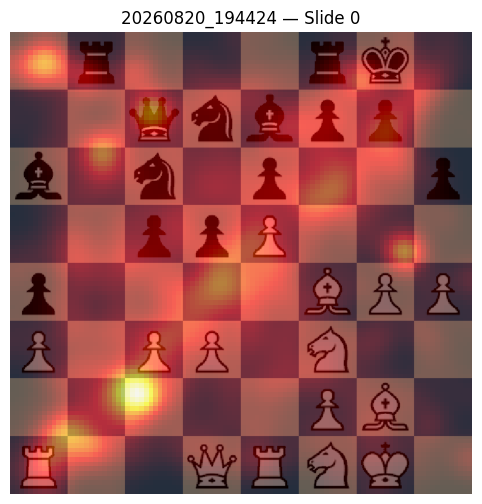

In [3]:
# Assuming you already have the data
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-29.430227,13.225609,4885


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260820_194424,-17.470503,-27.896498,713
1,20260823_120449,-25.108124,-2.134489,1808
2,20260823_120940,-14.057533,42.737009,1197
3,20260823_140228,-57.006374,28.164038,1111
4,20260823_183539,-102.745605,105.535924,56


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260820_194424,0,1.179036,-40.322591,84
1,20260820_194424,1,-8.599895,19.737567,82
2,20260820_194424,2,19.112971,8.852228,88
3,20260820_194424,3,26.683356,26.050495,82
4,20260820_194424,4,-73.648003,-51.091092,72


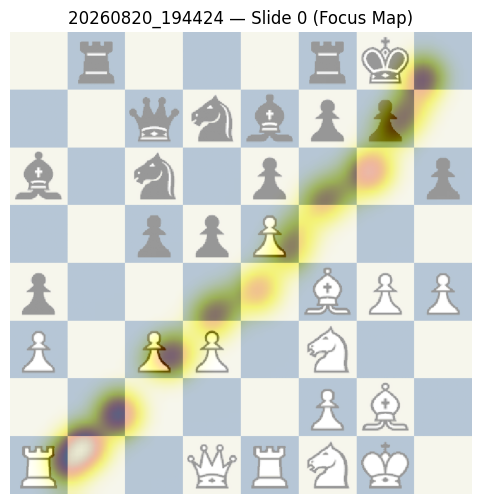

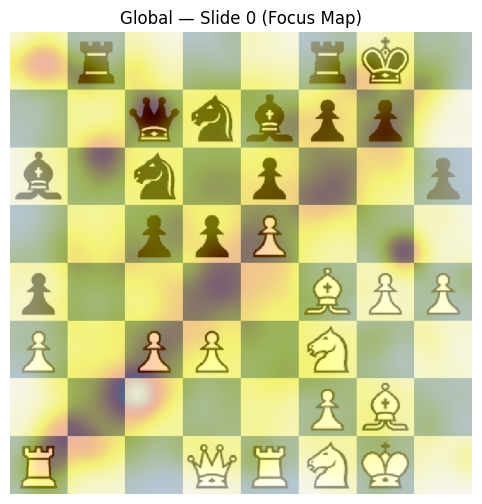

In [4]:
# --- Prepare background data ---
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260820_194424,0,41.701054,42.122687,0.442169,296.140625,303.363281,209.261719,148.480469,177.585557,833.559272,415.931370,8844.897468
1,20260820_194424,0,42.225510,42.225510,0.041289,205.183594,144.191406,205.183594,144.191406,0.000000,0.000000,0.000000,2991.899486
2,20260820_194424,0,42.266620,42.574469,0.328381,174.917969,126.539062,72.761719,11.003906,154.221502,1001.347450,555.642954,12312.409771
3,20260820_194424,0,42.615511,42.677075,0.082107,42.039062,-29.058594,23.953125,-48.554688,26.593210,678.740967,325.565708,28900.480799
4,20260820_194424,0,42.779692,43.077832,0.380296,19.695312,-48.898438,-118.734375,-152.847656,173.113311,1676.290329,457.619248,17435.654315


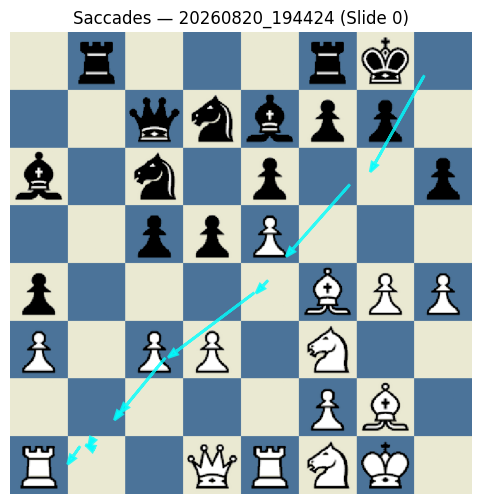

In [5]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,41.639413,41.844945,0.205532,292.503906,292.318848,63.035156,20260820_194424,0
1,41.855247,41.957876,0.102629,260.161458,232.918620,69.703125,20260820_194424,0
2,41.978390,42.081653,0.103262,222.182292,173.875000,74.578125,20260820_194424,0
3,42.102171,42.266620,0.164449,197.986328,140.961914,77.265625,20260820_194424,0
4,42.287107,42.410293,0.123185,128.521484,93.734375,88.410156,20260820_194424,0


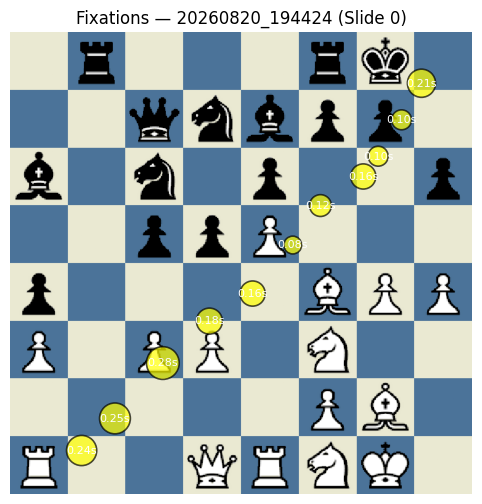

In [6]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,voice_file,voice_start_timestamp,event_type,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260820_194424,0,output/20260820_194424/frame_35_delay-1s.gif,./datasets/chess/good/frame_35_delay-1s.gif,chess,chess,None,NaN,NaN,MonocularEyeSampleEventNT,...,296.757812,306.300781,None,None,5,0,296.757812,306.300781,2.5,0
1,20260820_194424,0,output/20260820_194424/frame_35_delay-1s.gif,./datasets/chess/good/frame_35_delay-1s.gif,chess,chess,None,NaN,NaN,MonocularEyeSampleEventNT,...,296.757812,306.058594,None,None,5,0,296.757812,306.058594,2.5,0
2,20260820_194424,0,output/20260820_194424/frame_35_delay-1s.gif,./datasets/chess/good/frame_35_delay-1s.gif,chess,chess,None,NaN,NaN,MonocularEyeSampleEventNT,...,296.140625,303.363281,None,None,5,0,296.140625,303.363281,2.5,0
3,20260820_194424,0,output/20260820_194424/frame_35_delay-1s.gif,./datasets/chess/good/frame_35_delay-1s.gif,chess,chess,None,NaN,NaN,MonocularEyeSampleEventNT,...,295.175781,300.503906,None,None,5,0,295.175781,300.503906,2.5,0
4,20260820_194424,0,output/20260820_194424/frame_35_delay-1s.gif,./datasets/chess/good/frame_35_delay-1s.gif,chess,chess,None,NaN,NaN,MonocularEyeSampleEventNT,...,293.089844,294.257812,None,None,5,0,293.089844,294.257812,2.5,0


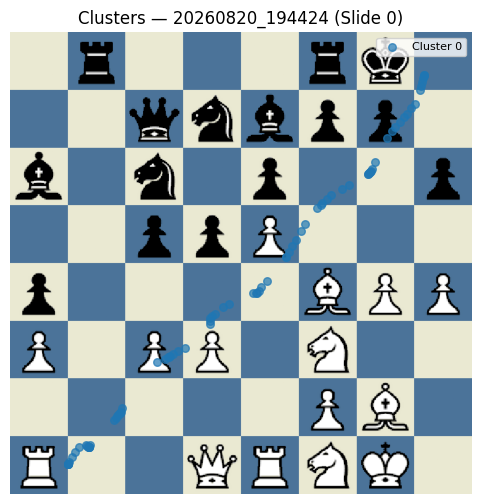

In [7]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

background_data= pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=example_slide["slide_index"],
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,5.609288,26632.777809,84,20260820_194424,0
1,5.212548,36674.196938,82,20260820_194424,1
2,5.747736,20157.994774,88,20260820_194424,2
3,5.930484,34443.028450,82,20260820_194424,3
4,5.700836,23748.658798,72,20260820_194424,4


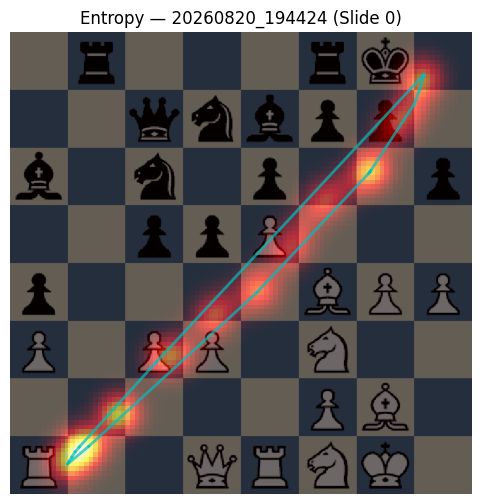

In [8]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)
